In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Desactivar advertencias de convergencia y algebra lineal para un output limpio
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# 1. CARGA DE DATOS Y CONSTRUCCIÓN DE REZAGOS
# ============================================================
df_procesados = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\2_datos_procesados\datos_procesados_originales\datos_procesados_sin_var_orig.xlsx")
df_procesados['fecha'] = pd.to_datetime(df_procesados['fecha'])
df_procesados.set_index('fecha', inplace=True)

variables_base = ['hum_esp_bc', 'hum_rel_bc', 'prec_ln', 'dias_lluvia_ln', 'vel_vi_max_bc', 'vel_vi_bc', 'temp_max_bc', 'sst_yj']
max_lag = 20

In [3]:
# Construcción eficiente de lags
lags_dict = {}
for lag in range(1, max_lag + 1):
    for var in variables_base:
        lags_dict[f'{var}_lag_{lag}'] = df_procesados[var].shift(lag)

df_lags = pd.DataFrame(lags_dict, index=df_procesados.index)
df_total = pd.concat([df_procesados[['año', 'semana_epi', 'casos_ln']], df_lags], axis=1).dropna()

In [4]:
# Selección de rezagos específicos según tu literatura
variables_pca_seleccionadas = [
    'hum_esp_bc_lag_2','hum_esp_bc_lag_3','hum_esp_bc_lag_4','hum_esp_bc_lag_5','hum_esp_bc_lag_6','hum_esp_bc_lag_7','hum_esp_bc_lag_8',
    'prec_ln_lag_4','prec_ln_lag_5','prec_ln_lag_6','prec_ln_lag_7','prec_ln_lag_8',
    'dias_lluvia_ln_lag_4','dias_lluvia_ln_lag_5','dias_lluvia_ln_lag_6',
    'vel_vi_max_bc_lag_2','vel_vi_max_bc_lag_3','vel_vi_max_bc_lag_4','vel_vi_max_bc_lag_5','vel_vi_max_bc_lag_6',
    'temp_max_bc_lag_5','temp_max_bc_lag_6','temp_max_bc_lag_7','temp_max_bc_lag_8',
    'sst_yj_lag_16','sst_yj_lag_17','sst_yj_lag_18','sst_yj_lag_19','sst_yj_lag_20'
]

X_climaticas = df_total[variables_pca_seleccionadas]
y_transf = df_total['casos_ln']
metadatos_tiempo = df_total[['año', 'semana_epi']]

In [5]:
# ============================================================
# 2. DEFINICIÓN DE ÓRDENES Y SPLITS (TU ARQUITECTURA)
# ============================================================
arima_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (2,1,2)]
sarima_orders = [((1,1,1),(1,1,1,52)), ((1,1,0),(1,1,1,52)), ((0,1,1),(1,1,1,52))]
arimax_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2)]
sarimax_orders = [((1,1,1),(1,1,1,52)), ((0,1,1),(1,1,1,52))]

porcentajes_train = [0.80, 0.90, 0.95]

In [6]:
# Listas para almacenar auditoría completa y mejores predicciones
todas_las_metricas = []
mejores_predicciones = {}

In [7]:
# ============================================================
# 3. EJECUCIÓN DEL GRID SEARCH MULTI-ESCALA
# ============================================================
for p_train in porcentajes_train:
    split_idx = int(len(df_total) * p_train)
    
    # Divisiones temporales estrictas
    X_train_c, X_test_c = X_climaticas.iloc[:split_idx], X_climaticas.iloc[split_idx:]
    y_train, y_test = y_transf.iloc[:split_idx], y_transf.iloc[split_idx:]
    time_train, time_test = metadatos_tiempo.iloc[:split_idx], metadatos_tiempo.iloc[split_idx:]
    
    # Escalado y PCA local (Evita filtración de datos futuros)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_c)
    X_test_scaled = scaler.transform(X_test_c)
    
    pca = PCA(n_components=4) # Retiene los 4 componentes principales principales
    X_train_pca = pd.DataFrame(pca.fit_transform(X_train_scaled), index=y_train.index)
    X_test_pca = pd.DataFrame(pca.transform(X_test_scaled), index=y_test.index)
    
    # --- Estructura interna para mapear ejecuciones ---
    experimentos = [
        {'tipo': 'ARIMA', 'ordenes': [(o, (0,0,0,0)) for o in arima_orders], 'exog_tr': None, 'exog_te': None},
        {'tipo': 'SARIMA', 'ordenes': sarima_orders, 'exog_tr': None, 'exog_te': None},
        {'tipo': 'ARIMAX', 'ordenes': [(o, (0,0,0,0)) for o in arimax_orders], 'exog_tr': X_train_pca, 'exog_te': X_test_pca},
        {'tipo': 'SARIMAX', 'ordenes': sarimax_orders, 'exog_tr': X_train_pca, 'exog_te': X_test_pca}
    ]
    
    for exp in experimentos:
        for orden_p, orden_s in exp['ordenes']:
            try:
                # Definición y ajuste del modelo con statsmodels
                model = SARIMAX(endog=y_train, exog=exp['exog_tr'], order=orden_p, seasonal_order=orden_s)
                fitted_model = model.fit(disp=False)
                
                # Predicciones logarítmicas
                pred_tr_ln = fitted_model.fittedvalues
                pred_te_ln = fitted_model.predict(start=y_test.index[0], end=y_test.index[-1], exog=exp['exog_te'])
                
                # REVERSIÓN A ESCALA REAL (Casos de Dengue)
                y_train_real = np.exp(y_train)
                y_test_real = np.exp(y_test)
                pred_tr_real = np.exp(pred_tr_ln)
                pred_te_real = np.exp(pred_te_ln)
                
                # Cálculo de métricas sobre números enteros/reales de casos
                # Se descarta el índice 0 en Train debido a la pérdida por diferenciación d=1
                mae_tr = mean_absolute_error(y_train_real.iloc[1:], pred_tr_real.iloc[1:])
                mae_te = mean_absolute_error(y_test_real, pred_te_real)
                rmse_tr = np.sqrt(mean_squared_error(y_train_real.iloc[1:], pred_tr_real.iloc[1:]))
                rmse_te = np.sqrt(mean_squared_error(y_test_real, pred_te_real))
                r2_tr = r2_score(y_train.iloc[1:], pred_tr_ln.iloc[1:])
                r2_te = r2_score(y_test, pred_te_ln)
                
                str_orden = f"order={orden_p}" if exp['tipo'] in ['ARIMA','ARIMAX'] else f"order={orden_p} seasonal={orden_s}"
                
                res_dict = {
                    'Split_Train': f'{int(p_train*100)}%',
                    'Modelo': exp['tipo'],
                    'Configuración': str_orden,
                    'MAE_Train': mae_tr, 'MAE_Test': mae_te,
                    'RMSE_Train': rmse_tr, 'RMSE_Test': rmse_te,
                    'R2_Train': r2_tr, 'R2_Test': r2_te
                }
                todas_las_metricas.append(res_dict)
                
                # Guardar estructura temporal de predicciones para análisis detallado o gráficos
                df_pred = time_test.copy()
                df_pred['Real'] = y_test_real
                df_pred['Predicho'] = pred_te_real
                mejores_predicciones[f"{exp['tipo']}_{int(p_train*100)}_{str_orden}"] = df_pred
                
            except Exception as e:
                # Captura combinaciones que no converjan matemáticamente
                continue

In [8]:
# ============================================================
# 4. EXTRACCIÓN Y PRESENTACIÓN DE LOS MEJORES RESULTADOS
# ============================================================
df_completo = pd.DataFrame(todas_las_metricas)

# Encontrar la mejor configuración (menor MAE_Test) por cada familia de modelo y cada Split
mejores_modelos_resumen = df_completo.loc[df_completo.groupby(['Split_Train', 'Modelo'])['MAE_Test'].idxmin()]

print("\n" + "="*85 + "\n   RESUMEN DE LOS MEJORES ÓRDENES ENCONTRADOS (EVALUADOS EN ESCALA REAL DE CASOS) \n" + "="*85)
print(mejores_modelos_resumen.to_string(index=False))


   RESUMEN DE LOS MEJORES ÓRDENES ENCONTRADOS (EVALUADOS EN ESCALA REAL DE CASOS) 
Split_Train  Modelo                          Configuración  MAE_Train  MAE_Test  RMSE_Train  RMSE_Test  R2_Train   R2_Test
        80%   ARIMA                        order=(2, 1, 1)   0.285975  1.997845    0.410874   2.279637  0.835251 -1.473020
        80%  ARIMAX                        order=(1, 1, 2)   0.281749  1.730814    0.412138   2.098917  0.840158 -1.273152
        80%  SARIMA order=(1, 1, 1) seasonal=(1, 1, 1, 52)   0.419256  3.447149    0.587014   4.311418  0.677845 -3.597438
        80% SARIMAX order=(1, 1, 1) seasonal=(1, 1, 1, 52)   0.415856  2.045329    0.573334   2.596919  0.690114 -1.833183
        90%   ARIMA                        order=(1, 1, 0)   0.306236  0.932536    0.436046   1.097541  0.854597 -1.282698
        90%  ARIMAX                        order=(1, 1, 0)   0.302544  1.079004    0.432645   1.216257  0.856583 -1.546248
        90%  SARIMA order=(1, 1, 0) seasonal=(1, 1, 1, 

In [9]:
# ============================================================
# 5. MUESTRA DE PREDICCIONES CON FECHA, AÑO Y SEMANA EPIDEMIOLÓGICA
# ============================================================
# Tomamos como ejemplo el mejor SARIMAX bajo el Split del 80%
mejor_sarimax_80_conf = df_completo[(df_completo['Modelo']=='SARIMAX') & (df_completo['Split_Train']=='80%')].sort_values(by='MAE_Test').iloc[0]['Configuración']
llave_busqueda = f"SARIMAX_80_{mejor_sarimax_80_conf}"

print(f"\n" + "="*85 + f"\n MUESTRA DE PREDICCIONES CRONOLÓGICAS (Mejor {llave_busqueda}) \n" + "="*85)
print(mejores_predicciones[llave_busqueda].head(12))


 MUESTRA DE PREDICCIONES CRONOLÓGICAS (Mejor SARIMAX_80_order=(1, 1, 1) seasonal=(1, 1, 1, 52)) 
             año  semana_epi      Real  Predicho
fecha                                           
2025-01-26  2025           5  5.350314  5.607843
2025-02-02  2025           6  5.480664  4.628516
2025-02-09  2025           7  3.919237  3.515202
2025-02-16  2025           8  4.239441  3.279818
2025-02-23  2025           9  3.023965  5.144864
2025-03-02  2025          10  4.465481  4.281889
2025-03-09  2025          11  3.547349  4.023786
2025-03-16  2025          12  4.148416  3.707772
2025-03-23  2025          13  2.829633  5.541187
2025-03-30  2025          14  2.829633  3.875866
2025-04-06  2025          15  2.975600  4.045231
2025-04-13  2025          16  2.975600  2.933730


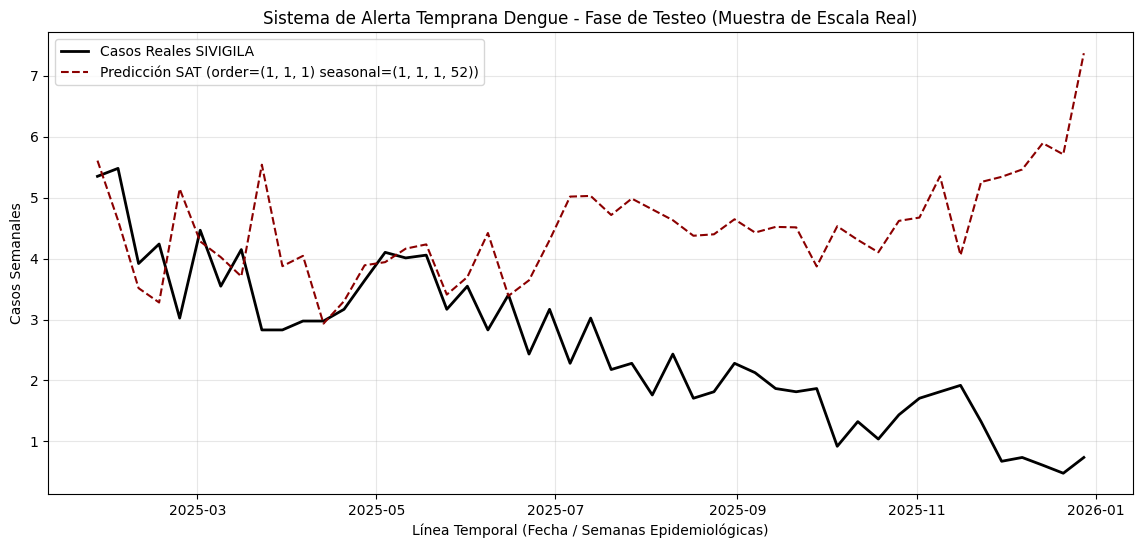

In [10]:
# ============================================================
# 6. GRÁFICO DE VALIDACIÓN DEL MODELO GANADOR (SPLIT 80%)
# ============================================================
plt.figure(figsize=(14, 6))
df_graficar = mejores_predicciones[llave_busqueda]
plt.plot(df_graficar.index, df_graficar['Real'], label='Casos Reales SIVIGILA', color='black', linewidth=2)
plt.plot(df_graficar.index, df_graficar['Predicho'], label=f'Predicción SAT ({mejor_sarimax_80_conf})', color='darkred', linestyle='--')
plt.title('Sistema de Alerta Temprana Dengue - Fase de Testeo (Muestra de Escala Real)')
plt.xlabel('Línea Temporal (Fecha / Semanas Epidemiológicas)')
plt.ylabel('Casos Semanales')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()